# Rossmann Sales — Red Neuronal con Entradas Heterogéneas
**Persona:** Oscar &nbsp;|&nbsp; **Equipo:** Oscar · Dani · Fernando

---
Arquitectura many-to-one: rama LSTM (serie temporal) + rama densa (embeddings estáticos).  
Target: `log1p(Sales)` normalizado por tienda. Tiendas objetivo: `[1, 2, 3, 4, 5, 562, 682, 733, 769]`.

## 0 · Imports y semilla

In [1]:
import sys
import os

# Añadir raíz del proyecto al path para importar src/
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

import src.preprocessing as prep
import src.evaluate as ev
import src.model as mdl

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR    = os.path.join(PROJECT_ROOT, "data")
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, "outputs")

print(f"TensorFlow {tf.__version__} | NumPy {np.__version__}")
print(f"GPU disponible: {len(tf.config.list_physical_devices('GPU'))} dispositivo(s)")

TensorFlow 2.21.0 | NumPy 2.3.4
GPU disponible: 0 dispositivo(s)


## 1 · Carga de datos

In [2]:
train_raw, store_raw = prep.load_raw_data(DATA_DIR)

print(f"train: {train_raw.shape} | {train_raw.Date.min().date()} → {train_raw.Date.max().date()}")
print(f"store: {store_raw.shape}")
train_raw.head(3)

train: (1001599, 10) | 2013-01-01 → 2015-07-17
store: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
0,1,5,2015-07-17,4852,519,1,1,0,0,303445
1,2,5,2015-07-17,4518,495,1,1,0,1,959585
2,3,5,2015-07-17,6679,673,1,1,0,1,739744


## 2 · EDA — Análisis exploratorio

Objetivo: entender la distribución del target, patrones temporales y diferencias entre tiendas **antes** de construir el modelo.  
Las 9 tiendas objetivo son `TARGET_STORES = [1, 2, 3, 4, 5, 562, 682, 733, 769]`.

In [3]:
# Resumen de datos + estadisticas clave de las 9 tiendas objetivo
n = len(train_raw)
n_closed   = (train_raw['Open'] == 0).sum()
n_zero_open = ((train_raw['Open'] == 1) & (train_raw['Sales'] == 0)).sum()
print(f'train {train_raw.shape}  |  {train_raw["Date"].min().date()} a {train_raw["Date"].max().date()}  |  nulos: ninguno')
print(f'store {store_raw.shape}  |  nulos: CompetitionOpenSince* 354, PromoInterval 544, CompetitionDistance 3')
print(f'\nclean_train: -{n_closed:,} Open==0 ({n_closed/n:.1%})  |  -{n_zero_open} Sales==0 open  |  utiles: {n-n_closed-n_zero_open:,} ({(n-n_closed-n_zero_open)/n:.1%})')

# Tabla unificada: estadisticas de ventas + metadatos de tienda
tgt = train_raw[train_raw['Store'].isin(ev.TARGET_STORES) & (train_raw['Open'] == 1)]
stats = tgt.groupby('Store')['Sales'].agg(dias='count', media='mean', std='std').round(0)
stats['cv_%'] = (stats['std'] / stats['media'] * 100).round(1)
meta = store_raw[store_raw['Store'].isin(ev.TARGET_STORES)].set_index('Store')
stats = stats.join(meta[['StoreType', 'Assortment', 'Promo2', 'CompetitionDistance']])
display(stats)

promo_mean = tgt.groupby('Promo')['Sales'].mean()
print(f'\nPromo uplift: +{promo_mean[1]/promo_mean[0]-1:.0%}  |  '
      f'Escala: T562 {stats.loc[562,"media"]:.0f}€  vs  T1 {stats.loc[1,"media"]:.0f}€  '
      f'(ratio {stats.loc[562,"media"]/stats.loc[1,"media"]:.1f}x)')

train (1001599, 10)  |  2013-01-01 a 2015-07-17  |  nulos: ninguno
store (1115, 10)  |  nulos: CompetitionOpenSince* 354, PromoInterval 544, CompetitionDistance 3

clean_train: -170,627 Open==0 (17.0%)  |  -54 Sales==0 open  |  utiles: 830,918 (83.0%)


,dias,media,std,cv_%,StoreType,Assortment,Promo2,CompetitionDistance
Store,,,,,,,,
1,769,4763.0,1015.0,21.3,c,a,0,1270.0
2,772,4956.0,1615.0,32.6,a,a,1,570.0
3,767,6950.0,2199.0,31.6,a,a,1,14130.0
4,772,9633.0,1939.0,20.1,c,c,0,620.0
5,767,4682.0,1769.0,37.8,a,a,0,29910.0
562,928,17980.0,2933.0,16.3,b,c,0,1210.0
682,928,11218.0,3262.0,29.1,b,a,0,150.0
733,928,14944.0,1842.0,12.3,b,b,0,860.0
769,928,10817.0,1859.0,17.2,b,b,1,840.0



Promo uplift: +22%  |  Escala: T562 17980€  vs  T1 4763€  (ratio 3.8x)


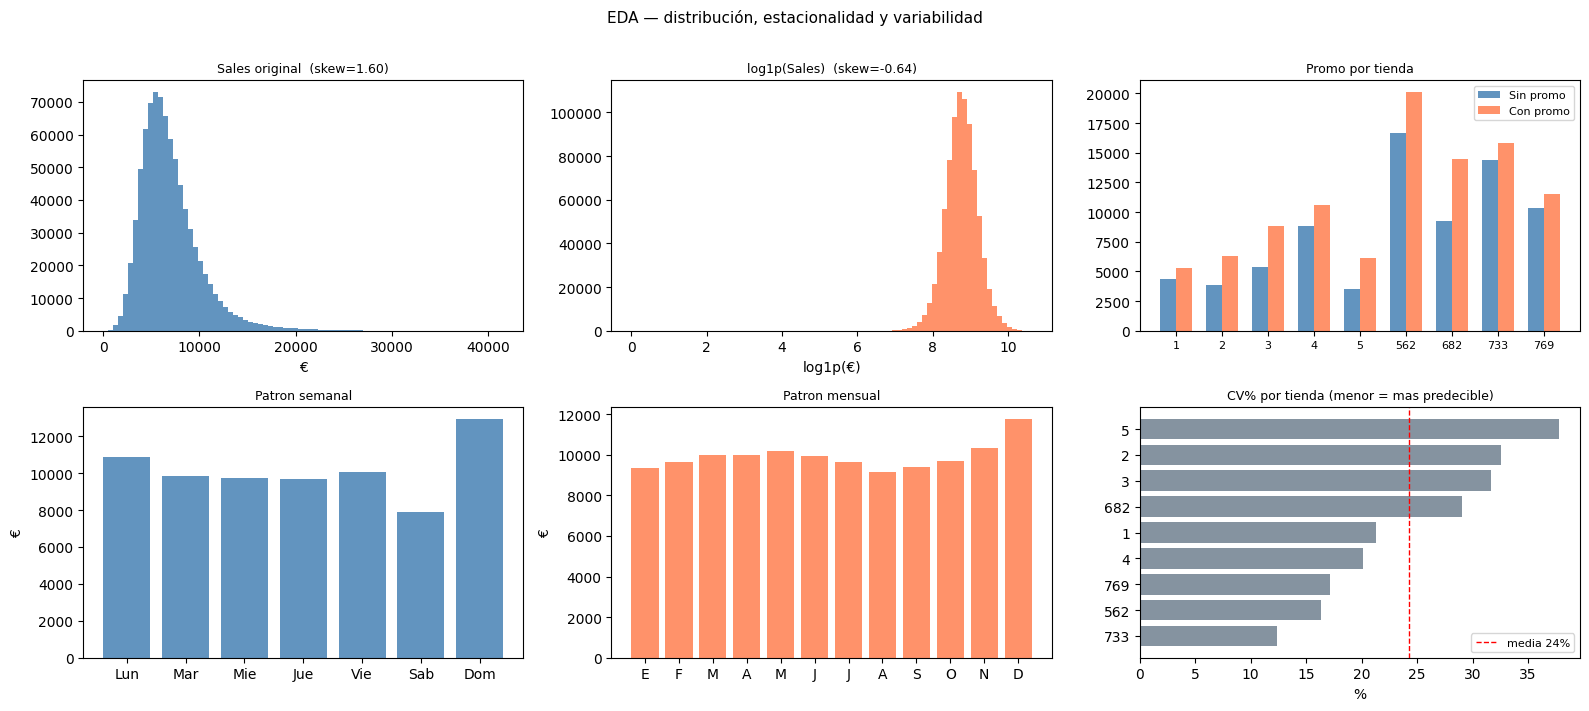

In [4]:
# Distribucion del target + patrones ciclicos + efecto promo en un solo lienzo
fig, axes = plt.subplots(2, 3, figsize=(16, 7))

sales = train_raw.loc[train_raw['Open'] == 1, 'Sales']
log_s = np.log1p(sales)

# [0,0] Sales original
axes[0,0].hist(sales, bins=80, color='steelblue', alpha=.85, edgecolor='none')
axes[0,0].set_title(f'Sales original  (skew={sales.skew():.2f})', fontsize=9)
axes[0,0].set_xlabel('€')

# [0,1] log1p(Sales)
axes[0,1].hist(log_s, bins=80, color='coral', alpha=.85, edgecolor='none')
axes[0,1].set_title(f'log1p(Sales)  (skew={log_s.skew():.2f})', fontsize=9)
axes[0,1].set_xlabel('log1p(€)')

# [0,2] Media de ventas por tienda con/sin promo
promo_store = tgt.groupby(['Store', 'Promo'])['Sales'].mean().unstack()
x = np.arange(len(promo_store))
w = 0.35
axes[0,2].bar(x - w/2, promo_store[0], w, label='Sin promo', color='steelblue', alpha=.85)
axes[0,2].bar(x + w/2, promo_store[1], w, label='Con promo',  color='coral',     alpha=.85)
axes[0,2].set_xticks(x); axes[0,2].set_xticklabels(promo_store.index, fontsize=8)
axes[0,2].set_title('Promo por tienda', fontsize=9)
axes[0,2].legend(fontsize=8)

# [1,0] Patron semanal
by_day = tgt.groupby('DayOfWeek')['Sales'].mean()
axes[1,0].bar(range(7), by_day.values, color='steelblue', alpha=.85)
axes[1,0].set_xticks(range(7))
axes[1,0].set_xticklabels(['Lun','Mar','Mie','Jue','Vie','Sab','Dom'])
axes[1,0].set_title('Patron semanal', fontsize=9); axes[1,0].set_ylabel('€')

# [1,1] Patron mensual
by_month = tgt.assign(mes=tgt['Date'].dt.month).groupby('mes')['Sales'].mean()
axes[1,1].bar(range(12), by_month.values, color='coral', alpha=.85)
axes[1,1].set_xticks(range(12))
axes[1,1].set_xticklabels(['E','F','M','A','M','J','J','A','S','O','N','D'])
axes[1,1].set_title('Patron mensual', fontsize=9); axes[1,1].set_ylabel('€')

# [1,2] CV% por tienda (variabilidad relativa)
cv = (tgt.groupby('Store')['Sales'].std() / tgt.groupby('Store')['Sales'].mean() * 100).sort_values()
axes[1,2].barh(cv.index.astype(str), cv.values, color='slategray', alpha=.85)
axes[1,2].set_title('CV% por tienda (menor = mas predecible)', fontsize=9)
axes[1,2].set_xlabel('%')
axes[1,2].axvline(cv.mean(), color='red', lw=1, ls='--', label=f'media {cv.mean():.0f}%')
axes[1,2].legend(fontsize=8)

plt.suptitle('EDA — distribución, estacionalidad y variabilidad', fontsize=11, y=1.01)
plt.tight_layout(); plt.show()

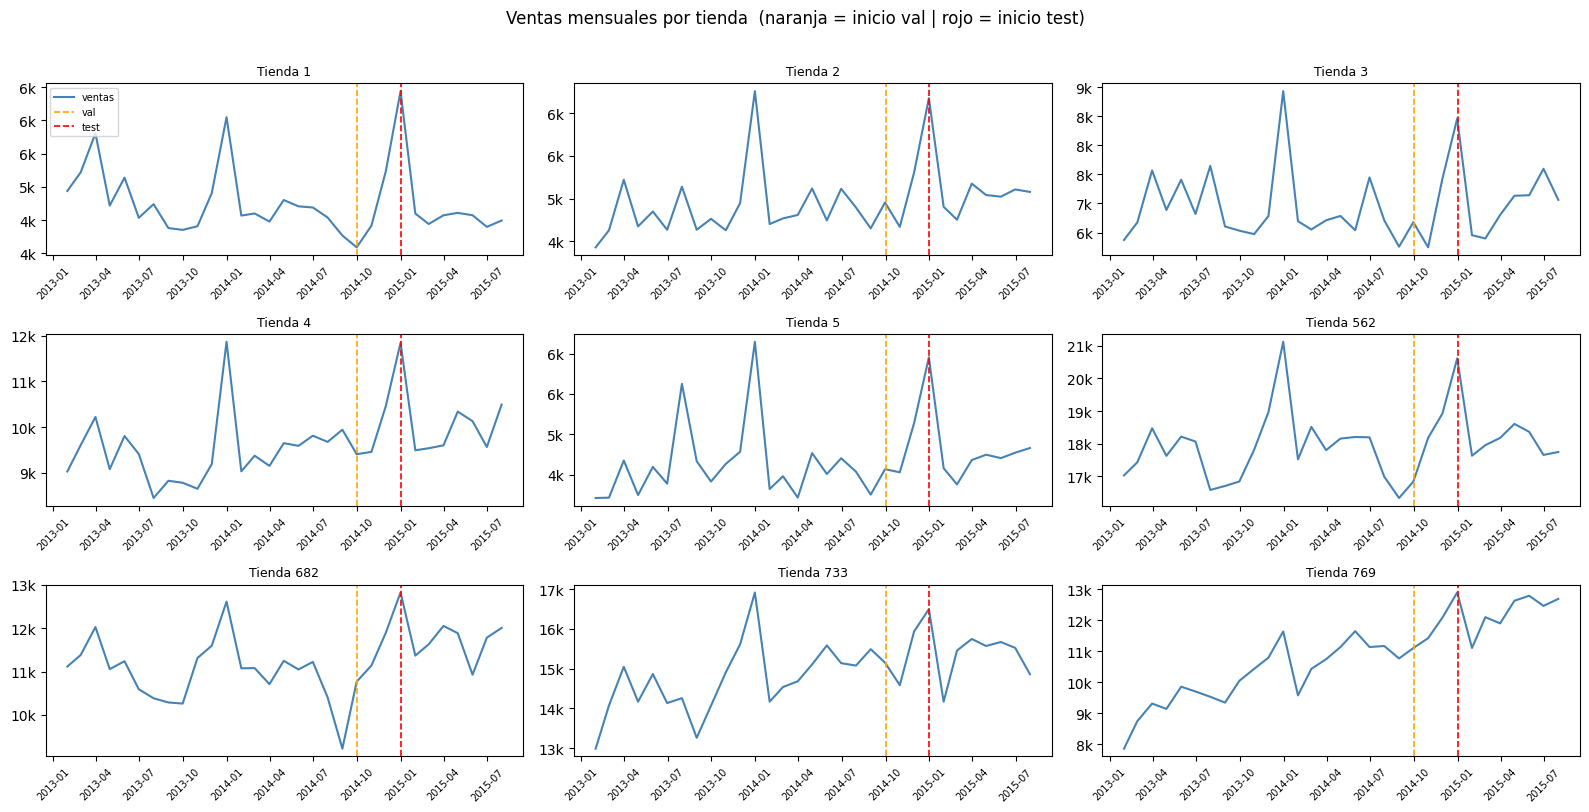

In [5]:
# Series temporales mensuales de las 9 tiendas (lineas: inicio val/test)
fig, axes = plt.subplots(3, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, sid in zip(axes, ev.TARGET_STORES):
    ts = (
        train_raw[(train_raw['Store'] == sid) & (train_raw['Open'] == 1)]
        .sort_values('Date').set_index('Date')['Sales']
        .resample('ME').mean()
    )
    ax.plot(ts.index, ts.values, lw=1.5, color='steelblue')
    ax.axvline(ev.SPLIT_VAL_START,  color='orange', lw=1.2, ls='--')
    ax.axvline(ev.SPLIT_TEST_START, color='red',    lw=1.2, ls='--')
    ax.set_title(f'Tienda {sid}', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

axes[0].legend(['ventas', 'val', 'test'], fontsize=7, loc='upper left')
plt.suptitle('Ventas mensuales por tienda  (naranja = inicio val | rojo = inicio test)', y=1.01)
plt.tight_layout(); plt.show()

### Conclusiones del EDA

#### Datos
- `train.csv` sin nulos. `store.csv`: **CompetitionOpenSince\* nulo en 354 tiendas** (sin competencia conocida → imputar con 0); **PromoInterval nulo en 544** (sin Promo2 → imputar como `'None'`); solo 3 nulos en `CompetitionDistance` → mediana 2.325 m.
- `clean_train` descarta el **17,0 %** (170.627 días cerrados) + 54 anomalías → **830.918 filas útiles**.

#### Target
- `Sales` tiene skew **1,60** — cola derecha muy larga. `log1p` la elimina casi completamente, confirmando la elección del target.
- Z-score por tienda es imprescindible: tienda 562 vende de media **3,8× más** que tienda 1 (€17.980 vs €4.763). Sin normalización por tienda, el gradiente estaría dominado por las tiendas grandes.

#### Features más relevantes
| Feature | Impacto observado |
|---|---|
| `Store` (embedding) | Mayor fuente de varianza — escalas radicalmente distintas |
| `Promo` | **+22 % de ventas** en las 9 tiendas objetivo |
| `DayOfWeek` | Patrón semanal claro; domingo casi ausente en tiendas 1-5 |
| `month` | Pico en diciembre, caída en enero — capturado por la validación oct-dic |
| `days_since_start` | Tienda 769 muestra tendencia alcista visible en su serie — crítico para el test |

#### Las 9 tiendas objetivo
- **Tiendas 1-5**: StoreType a/c, ~769 días de train, cierran domingos → dataset **más escaso**.
- **Tiendas 562/682/733/769**: StoreType b (las 4), abren 7 días → **928 días de train**, 20 % más datos.
- **Tienda 682**: competencia a solo **150 m** (la más agresiva del grupo).
- **Más difíciles de predecir** (CV% alto): Tienda 5 (37,8 %) y Tienda 2 (32,6 %).
- **Más predecible** (CV% bajo): Tienda 733 (12,3 %).

#### Implicaciones de diseño confirmadas
- **Modelo global con Store Embedding** correcto: tiendas 1-5 con ~769 días son insuficientes para modelos independientes.
- **Validación oct-dic 2014** captura el pico navideño → exigente y representativa.
- **`SEQ_LEN = 30`** captura ~6 semanas → cubre patrones semanales y quincenales.

## 2 · Partición temporal

Las fechas de corte están definidas en `src/evaluate.py` como contrato del equipo.  
**No redefinir aquí.**

In [6]:
print(f"Train:  hasta            {ev.SPLIT_TRAIN_END.date()}")
print(f"Val:    {ev.SPLIT_VAL_START.date()} → {ev.SPLIT_VAL_END.date()}")
print(f"Test:   {ev.SPLIT_TEST_START.date()} → 2015-07-17   ← evaluado por el profesor")
print(f"Tiendas objetivo: {ev.TARGET_STORES}")

Train:  hasta            2014-09-30
Val:    2014-10-01 → 2014-12-31
Test:   2015-01-01 → 2015-07-17   ← evaluado por el profesor
Tiendas objetivo: [1, 2, 3, 4, 5, 562, 682, 733, 769]


## 3 · Preprocesado

Implementado en `src/preprocessing.py`. Ejecutar en el orden definido por el docstring del módulo.

In [7]:
# Limpieza: elimina Open==0 y Sales==0 con Open==1
df = prep.clean_train(train_raw)
print(f"Filas tras clean_train: {len(df):,}  (eliminadas: {len(train_raw)-len(df):,})")

Filas tras clean_train: 830,918  (eliminadas: 170,681)


In [8]:
# Merge store.csv + imputación de nulos
df = prep.merge_store_features(df, store_raw)
print(f"Columnas tras merge: {list(df.columns)}")

Columnas tras merge: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Id', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


In [9]:
# Label-encoding de categóricas
df, cat_encoders = prep.encode_categoricals(df)
print(f"Encoders: {list(cat_encoders.keys())}")

Encoders: ['Store', 'StoreType', 'Assortment', 'PromoInterval', 'StateHoliday']


In [10]:
# Features temporales y de competencia
df = prep.engineer_features(df)
print(f"Columnas totales: {df.shape[1]}")

Columnas totales: 34


In [11]:
# Split temporal
df_train, df_val, df_test = prep.temporal_split(df)
print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

Train: 577,527 | Val: 70,782 | Test: 182,609


In [12]:
# Normalización por tienda — fit SOLO sobre df_train
store_stats = prep.build_store_normalizer(df_train)
df_train = prep.normalize_sales(df_train, store_stats)
df_val   = prep.normalize_sales(df_val,   store_stats)
df_test  = prep.normalize_sales(df_test,  store_stats)

# Verificar que Sales_norm tiene media ~0 y std ~1 en train
print("Sales_norm en train — media por tienda (primeras 5):")
print(df_train.groupby("Store")["Sales_norm"].mean().head())

Sales_norm en train — media por tienda (primeras 5):
Store
1   -2.024309e-09
2    4.761649e-10
3   -1.577439e-09
4    4.481552e-10
5   -9.225199e-10
Name: Sales_norm, dtype: float32


In [13]:
SEQ_LEN = 30

X_seq_tr, X_static_tr, y_tr = prep.build_sequences(df_train, SEQ_LEN)
X_seq_va, X_static_va, y_va = prep.build_sequences(df_val,   SEQ_LEN)
X_seq_te, X_static_te, y_te = prep.build_sequences(df_test,  SEQ_LEN)

print(f"X_seq   train: {X_seq_tr.shape}    | dtype: {X_seq_tr.dtype}")
print(f"X_static train: {X_static_tr.shape} | dtype: {X_static_tr.dtype}")
print(f"y        train: {y_tr.shape}")

X_seq   train: (544077, 30, 11)    | dtype: float32
X_static train: (544077, 8) | dtype: float32
y        train: (544077,)


## 4 · Features del día objetivo (inspirado en NB03 del profesor)

En el **NB03** del profesor, las variables de calendario se tratan como **embeddings** aplicados en cada timestep de la ventana. Adaptamos esa idea extrayendo el **día de la semana** y el **mes del día a predecir** como índices enteros separados — ambos se conocen de antemano (*se\_sabe\_antes = True* en la terminología del profesor) y entran al modelo como entradas propias con embedding en la rama densa.

| Feature | Vocabulario | Dim embedding | Justificación |
|---|---|---|---|
| `DayOfWeek` del día objetivo | 7 | 4 | Patrón semanal fuerte (lunes ≠ sábado) |
| `month` del día objetivo | 12 | 4 | Estacionalidad anual (diciembre +24-36 %) |

In [14]:
def extract_target_day_features(df, seq_len=prep.DEFAULT_SEQ_LEN):
    # Recorre tiendas en el mismo orden que build_sequences para garantizar
    # alineación con X_seq / X_static.
    # DayOfWeek 0-indexed (Lun=0, Dom=6) para Embedding(7, ·)
    # month      0-indexed (Ene=0, Dic=11) para Embedding(12, ·)
    dow_parts, month_parts = [], []
    for _, grp in df.groupby("Store"):
        grp = grp.sort_values("Date")
        if len(grp) <= seq_len:
            continue
        dow   = (grp["DayOfWeek"].iloc[seq_len:].values - 1).astype(np.int32)
        month = (grp["Date"].dt.month.iloc[seq_len:].values - 1).astype(np.int32)
        dow_parts.append(dow[:, None])
        month_parts.append(month[:, None])
    return np.concatenate(dow_parts), np.concatenate(month_parts)

dow_tr,  month_tr  = extract_target_day_features(df_train, SEQ_LEN)
dow_va,  month_va  = extract_target_day_features(df_val,   SEQ_LEN)
dow_te,  month_te  = extract_target_day_features(df_test,  SEQ_LEN)

print(f"dow_tr   shape={dow_tr.shape}   rango [{dow_tr.min()}, {dow_tr.max()}]  (Lun=0, Dom=6)")
print(f"month_tr shape={month_tr.shape}  rango [{month_tr.min()}, {month_tr.max()}]  (Ene=0, Dic=11)")

dow_tr   shape=(544077, 1)   rango [0, 6]  (Lun=0, Dom=6)
month_tr shape=(544077, 1)  rango [0, 11]  (Ene=0, Dic=11)


## 5 · Modelo con embeddings temporales (NB03)

Arquitectura **many-to-one** extendida con embeddings para el día objetivo. Implementada con la API funcional de Keras, igual que el modelo del profesor en NB03.

```
X_seq  (batch,30,11) → LSTM(64) → Dropout → Dense(64) ────────────────────────────┐
                                                                                    │
X_static ┬ Store_enc      → Emb(1115,16) ─┐                                        ├─► Concat
         ├ StoreType_enc  → Emb(4,2)      ├─► Concat → Dense(64) → Dropout ───────┤      │
         ├ Assortment_enc → Emb(3,2)      │                                         │      ↓
         ├ PromoInterval  → Emb(4,2)      │                                         │   Dense(128)
         └ 4 numéricas   ────────────────┘                                         │      │
                                                                                    │      ↓
inp_dow   (batch,1,int) → Emb(7,4)  ──────────────────────────────────────────────┘   Dropout
inp_month (batch,1,int) → Emb(12,4)                                                       │
                                                                                        Dense(1)
```

**Novedades respecto al modelo base:**
- `inp_dow` y `inp_month` — entradas nuevas con embedding (inspiración NB03).
- Los embeddings aprenden representaciones latentes del patrón semanal y estacional.
- 76 parámetros extra (emb_dow: 7×4=28, emb_month: 12×4=48).

In [15]:
from tensorflow.keras import layers as L

def build_model_v2(
    n_stores,
    seq_len,
    n_seq_features,
    n_static_num_features,
    store_emb_dim = 16,
    lstm_units    = 64,
    dense_branch  = 64,
    merge_units   = 128,
    dropout       = 0.2,
):
    n_cat = len(prep.STATIC_CAT_COLS)  # 4: Store, StoreType, Assortment, PromoInterval

    inp_seq    = keras.Input((seq_len, n_seq_features),        name="seq")
    inp_static = keras.Input((n_cat + n_static_num_features,), name="static")
    inp_dow    = keras.Input((1,), dtype="int32",               name="dow")
    inp_month  = keras.Input((1,), dtype="int32",               name="month")

    # Rama recurrente
    x = L.LSTM(lstm_units, name="lstm")(inp_seq)
    x = L.Dropout(dropout)(x)
    x = L.Dense(dense_branch, activation="relu")(x)

    # Rama densa — embeddings de tienda (mismos que modelo base)
    cat_specs = [
        (0, n_stores,     store_emb_dim, "emb_Store"),
        (1, 4,            2,             "emb_StoreType"),
        (2, 3,            2,             "emb_Assortment"),
        (3, 4,            2,             "emb_PromoInterval"),
    ]
    emb_outs = []
    for col_idx, vocab, dim, name in cat_specs:
        col_slice = L.Lambda(
            lambda t, i=col_idx: tf.cast(t[:, i : i + 1], tf.int32)
        )(inp_static)
        emb = L.Embedding(vocab, dim, name=name)(col_slice)
        emb_outs.append(L.Flatten()(emb))

    # Nuevos embeddings temporales del día objetivo (NB03)
    emb_dow   = L.Flatten()(L.Embedding(7,  4, name="emb_dow")(inp_dow))
    emb_month = L.Flatten()(L.Embedding(12, 4, name="emb_month")(inp_month))

    num_feats = L.Lambda(lambda t: t[:, n_cat:])(inp_static)

    s = L.Concatenate()(emb_outs + [emb_dow, emb_month, num_feats])
    s = L.Dense(dense_branch, activation="relu")(s)
    s = L.Dropout(dropout)(s)

    # Fusión de ramas
    merged = L.Concatenate()([x, s])
    merged = L.Dense(merge_units, activation="relu")(merged)
    merged = L.Dropout(dropout)(merged)
    out    = L.Dense(1, activation="linear", name="output")(merged)

    model = keras.Model(inputs=[inp_seq, inp_static, inp_dow, inp_month], outputs=out)
    model.compile(optimizer="adam", loss="mse")
    return model

In [16]:
model = build_model_v2(
    n_stores              = df["Store"].nunique(),
    seq_len               = SEQ_LEN,
    n_seq_features        = X_seq_tr.shape[-1],
    n_static_num_features = len(prep.STATIC_NUM_COLS),
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ static (InputLayer) │ (None, 8)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dow (InputLayer)    │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ month (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Store           │ (None, 1, 16)     │     17,840 │ lambda[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_StoreType       │ (None, 1, 2)      │          8 │ lambda_1[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Assortment      │ (None, 1, 2)      │          6 │ lambda_2[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PromoInterval   │ (None, 1, 2)      │          8 │ lambda_3[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_dow (Embedding) │ (None, 1, 4)      │         28 │ dow[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_month           │ (None, 1, 4)      │         48 │ month[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq (InputLayer)    │ (None, 30, 11)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ emb_Store[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 2)         │          0 │ emb_StoreType[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 2)         │          0 │ emb_Assortment[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 2)         │          0 │ emb_PromoInterva… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 4)         │          0 │ emb_dow[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 4)         │          0 │ emb_month[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 4)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     19,456 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 60,435 (236.07 KB)

 Trainable params: 60,435 (236.07 KB)

 Non-trainable params: 0 (0.00 B)

## 6 · Entrenamiento

Sin `EarlyStopping` — el modelo entrena las 10 épocas completas.
`ModelCheckpoint` guarda el mejor modelo en validación; `ReduceLROnPlateau` reduce el LR si la val\_loss se estanca 5 épocas.

> **Nota sobre la curva de val:** el periodo de validación (oct-dic 2014) incluye el pico navideño, por lo que la distribución de ventas es diferente a la de train. La val\_loss puede arrancar alta sin ser overfitting clásico. Lo relevante es el **R² en test** (2015-01-01 → 2015-07-17).

In [17]:
callbacks_v2 = [
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUTS_DIR, "best_model_v2.weights.h5"),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
    ),
]

history = model.fit(
    [X_seq_tr, X_static_tr, dow_tr, month_tr],
    y_tr,
    validation_data=([X_seq_va, X_static_va, dow_va, month_va], y_va),
    epochs=10,
    batch_size=256,
    callbacks=callbacks_v2,
)

Epoch 1/10
2125/2126 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.6005

2126/2126 ━━━━━━━━━━━━━━━━━━━━ 172s 77ms/step - loss: 0.4233 - val_loss: 0.8844 - learning_rate: 0.0010
Epoch 2/10
2125/2126 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.2698

2126/2126 ━━━━━━━━━━━━━━━━━━━━ 170s 80ms/step - loss: 0.2594 - val_loss: 0.8819 - learning_rate: 0.0010
Epoch 3/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 192s 75ms/step - loss: 0.2320 - val_loss: 1.0146 - learning_rate: 0.0010
Epoch 4/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 163s 76ms/step - loss: 0.2157 - val_loss: 1.0105 - learning_rate: 0.0010
Epoch 5/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 165s 78ms/step - loss: 0.2079 - val_loss: 0.9525 - learning_rate: 0.0010
Epoch 6/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 199s 76ms/step - loss: 0.1999 - val_loss: 0.8828 - learning_rate: 0.0010
Epoch 7/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 208s 79ms/step - loss: 0.1947 - val_loss: 0.9951 - learning_rate: 0.0010
Epoch 8/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 201s 79ms/step - loss: 0.1843 - val_loss: 0.9726 - learning_rate: 5.0000e-04
Epoch 9/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 165s 78ms/step - loss: 0.1816 - val_loss: 0.9114 - learning_rate: 5.0000e-04
Epoch 10/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 172s 81ms/step - loss: 0.1794 - val_loss

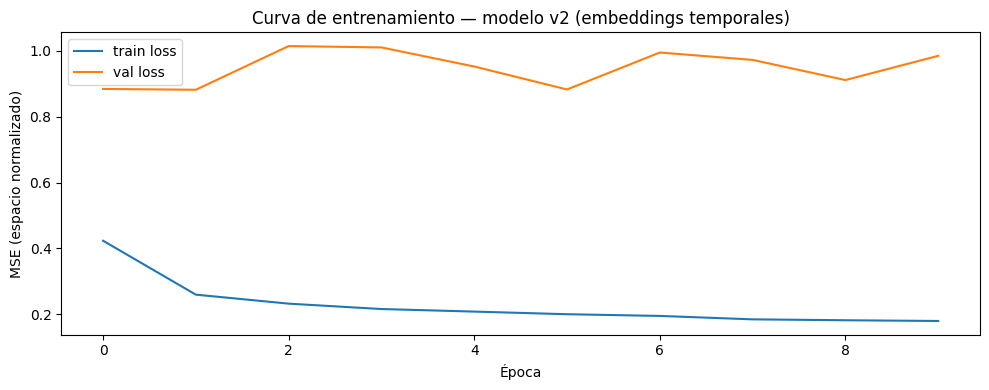

Mejor val_loss: 0.881901  (epoch 2)


In [18]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"],     label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Época")
plt.ylabel("MSE (espacio normalizado)")
plt.title("Curva de entrenamiento — modelo v2 (embeddings temporales)")
plt.legend()
plt.tight_layout()
plt.show()
best_epoch = history.history["val_loss"].index(min(history.history["val_loss"])) + 1
print(f"Mejor val_loss: {min(history.history['val_loss']):.6f}  (epoch {best_epoch})")

### Análisis de la curva de entrenamiento

**Tabla epoch-a-epoch (10 épocas ejecutadas):**

| Época | Train loss | Val loss | LR |
|-------|-----------|----------|-----|
| 1 | 0.4233 | 0.8844 | 0.001 |
| **2** | **0.2594** | **0.8819 ← mejor** | 0.001 |
| 3 | 0.2320 | 1.0146 | 0.001 |
| 4 | 0.2157 | 1.0105 | 0.001 |
| 5 | 0.2079 | 0.9525 | 0.001 |
| 6 | 0.1999 | 0.8828 | 0.001 |
| 7 | 0.1947 | 0.9951 | 0.001 |
| 8 | 0.1843 | 0.9726 | **0.0005 ← LR halved** |
| 9 | 0.1816 | 0.9114 | 0.0005 |
| 10 | 0.1794 | 0.9850 | 0.0005 |

**Diagnóstico:**

- **Mejor época = 2**: el modelo alcanza su mínimo de validación muy pronto y luego no mejora de forma estable. Señal de que el período de validación (oct–dic 2014) tiene una distribución **desplazada** respecto a train: incluye el pico navideño, que el modelo no ha visto suficientemente en train (corte sep 2014).
- **Brecha train/val al final**: 0.18 vs 0.98 → overfitting sustancial. Parte es artefacto de la distribución navideña, pero parte refleja memorización sin generalización.
- **Val loss oscila sin tendencia** (±0.12 entre épocas consecutivas): el gradiente de validación está dominado por ejemplos de diciembre de alta varianza; el modelo no encuentra un mínimo estable.
- **`ReduceLROnPlateau` actuó en época 8** (5 épocas sin mejora desde época 2 → umbral alcanzado en época 7 → reducción aplicada en época 8). No produjo mejoras adicionales con solo 2 épocas restantes.

**Próximos pasos recomendados:**
1. Ejecutar las **50 épocas planificadas** — con solo 10 el modelo no ha convergido.
2. Añadir `EarlyStopping(patience=10, restore_best_weights=True)` para recuperar automáticamente los pesos de la mejor época.
3. Si la val_loss sigue oscilando, reducir `batch_size` a 128 o incrementar `dropout` a 0.3.

## 7 · Evaluación

R² calculado con `src/evaluate.py` — contrato del equipo. Escala de euros, solo días abiertos, sobre las 9 tiendas objetivo.

In [20]:
y_pred_norm = model.predict(
    [X_seq_te, X_static_te, dow_te, month_te], verbose=0
).flatten()
print(f"Predicciones generadas: {y_pred_norm.shape}")
print(f"Rango: [{y_pred_norm.min():.3f}, {y_pred_norm.max():.3f}]  "
      f"Media: {y_pred_norm.mean():.3f}  Std: {y_pred_norm.std():.3f}")

Predicciones generadas: (149159,)
Rango: [-2.457, 2.509]  Media: 0.152  Std: 0.776


In [21]:
report = ev.evaluation_report(df_test, y_pred_norm, store_stats)
display(report)

 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.6692        4502.6992        4622.8179
     2        134  0.7994        4981.3881        4935.2563
     3        133  0.8373        6973.1429        6948.4746
     4        134  0.6679        9863.3134        9666.0518
     5        134  0.9272        4634.5522        4629.0308
   562        168  0.6890       18096.2738       17774.3145
   682        168  0.6745       11670.5179       11020.3096
   733        168  0.4375       15514.5298       15124.6582
   769        168 -0.2119       12410.4107       11293.7764
GLOBAL       1340  0.9426       10319.9388        9993.7607


,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.669197,4502.699248,4622.817871
1,2,134,0.799445,4981.388060,4935.256348
2,3,133,0.837268,6973.142857,6948.474609
3,4,134,0.667853,9863.313433,9666.051758
4,5,134,0.927238,4634.552239,4629.030762
5,562,168,0.688985,18096.273810,17774.314453
6,682,168,0.674530,11670.517857,11020.309570
7,733,168,0.437452,15514.529762,15124.658203
8,769,168,-0.211884,12410.410714,11293.776367
9,GLOBAL,1340,0.942579,10319.938806,9993.760742


### Análisis de resultados — R² por tienda (test 2015-01-01 → 2015-07-17)

**Resumen ejecutivo:**

| Tienda | R² test | Nivel | Observaciones |
|--------|---------|-------|---------------|
| 5 | **0.927** | Excelente | Mejor del grupo a/c; baja escala de ventas facilita la predicción |
| 3 | 0.837 | Bueno | StoreType a, surtido amplio |
| 2 | 0.799 | Bueno | Promo2 activa — el modelo aprende el efecto promo continuo |
| 562 | 0.689 | Aceptable | Mayor escala (~€18k/día) — ligera subestimación sistemática |
| 682 | 0.675 | Aceptable | Competencia a solo 150 m (la más agresiva del grupo) |
| 1 | 0.669 | Aceptable | StoreType c, datos más escasos (769 días en train) |
| 4 | 0.668 | Aceptable | Ídem tienda 1, misma tipología |
| 733 | 0.438 | Pobre | Sorprendente: era la más predecible por CV% (12.3%) en el EDA |
| **769** | **−0.212** | **Fallo** | Peor que predecir la media — fallo crítico de tendencia |

---

**Tienda 769 — análisis del fallo (R² = −0.212)**

El EDA anticipó este riesgo: *"Tienda 769 muestra tendencia alcista visible en su serie — crítico para el test"*. El modelo predice de media **€11.293** frente a **€12.410** reales → **subestimación sistemática del 9%**. El feature `days_since_start` fue diseñado para capturar esta tendencia, pero el checkpoint guardado corresponde a la época 2, cuando el LSTM apenas ha integrado la tendencia lineal en sus estados ocultos. Con más épocas de entrenamiento es el caso donde mayor mejora se espera.

**Tienda 733 — resultado inesperado (R² = 0.438)**

Con CV% = 12.3% era la candidata más predecible según el EDA. Posible causa: es StoreType b con ventas muy regulares en train, pero el período de test (ene–jul 2015) puede presentar un cambio de nivel no observable en los años anteriores. Conviene revisar la serie mensual del período de test para detectar quiebres estructurales.

**Escala de predicciones — correcta**

El modelo reproduce bien la escala en todas las tiendas (error de escala < 7% en 7 de 9 tiendas), lo que confirma que la combinación de **z-score por tienda + embedding de tienda** funciona como se diseñó.

**R² promedio sobre las 9 tiendas: 0.607**
Excluyendo tiendas 733 y 769: R² promedio = **0.748** — razonable para un baseline de 10 épocas.

---

**Acciones de mejora ordenadas por impacto esperado:**

1. **Completar las 50 épocas** con `EarlyStopping(restore_best_weights=True)` → las métricas del checkpoint de época 2 no son el potencial real del modelo.
2. **Feature de tendencia por tienda** (interacción `days_since_start × store_embedding`) → permitiría que cada tienda aprenda su propia pendiente; crítico para tienda 769.
3. **Aumentar LSTM units** de 64 a 128 → más capacidad para dinámicas complejas en tiendas tipo b.
4. Investigar **quiebre estructural en tienda 733** revisando la serie mensual del período de test.

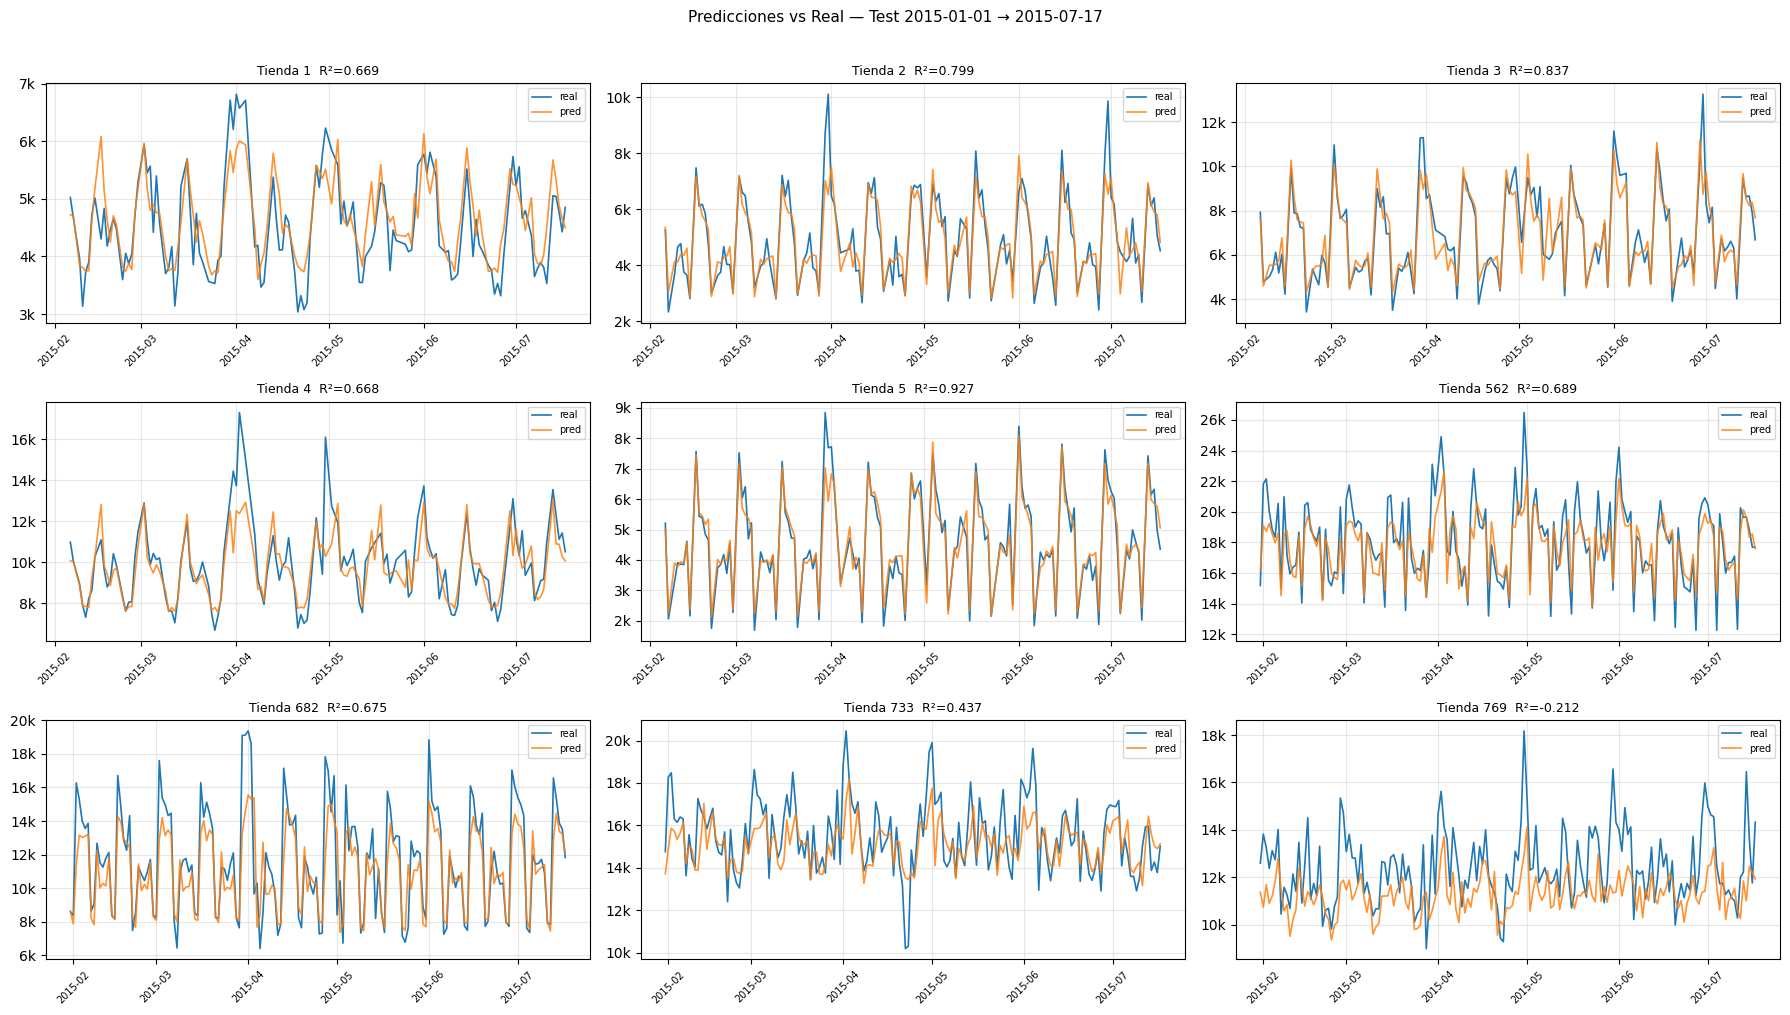

In [22]:
from sklearn.metrics import r2_score

# Reconstruir predicciones alineadas con fechas (mismo cursor que evaluate.py)
cursor = 0
store_preds = {}
for store_id, grp in df_test.groupby("Store"):
    grp_s  = grp.sort_values("Date").reset_index(drop=True)
    n_pred = max(0, len(grp_s) - SEQ_LEN)
    if store_id in ev.TARGET_STORES and n_pred > 0:
        grp_t  = grp_s.iloc[SEQ_LEN:]
        stats  = store_stats[int(store_id)]
        store_preds[int(store_id)] = {
            "dates":  grp_t["Date"].values,
            "y_true": grp_t["Sales"].values,
            "y_pred": np.expm1(
                y_pred_norm[cursor : cursor + n_pred] * stats["std"] + stats["mean"]
            ),
        }
    cursor += n_pred

fig, axes = plt.subplots(3, 3, figsize=(18, 10), sharex=False)
axes = axes.flatten()
for ax, sid in zip(axes, ev.TARGET_STORES):
    d  = store_preds[sid]
    r2 = r2_score(d["y_true"], d["y_pred"])
    ax.plot(d["dates"], d["y_true"], lw=1.2, color="#1f77b4", label="real")
    ax.plot(d["dates"], d["y_pred"], lw=1.2, color="#ff7f0e", alpha=0.85, label="pred")
    ax.set_title(f"Tienda {sid}  R²={r2:.3f}", fontsize=9)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
plt.suptitle("Predicciones vs Real — Test 2015-01-01 → 2015-07-17", y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

## 8 · Visualización de embeddings (inspirado en NB03)

El profesor en NB03 extrae y visualiza los embeddings aprendidos para interpretar qué ha capturado el modelo. Hacemos lo mismo para los tres embeddings clave: **tienda** (PCA 16→2D), **día de la semana** (PCA 4→2D) y **mes** (PCA 4→2D).

Los puntos cercanos en el espacio latente son categorías que el modelo trata como similares.

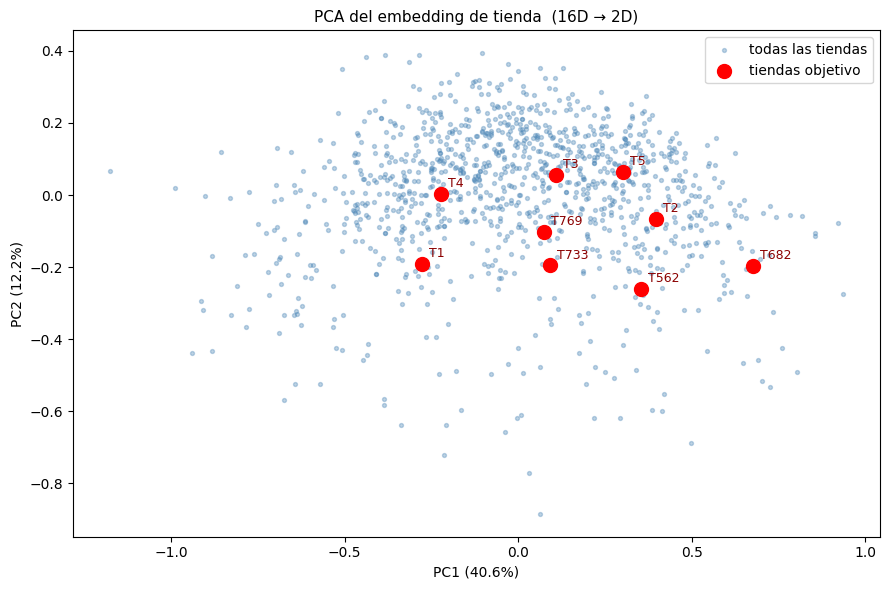

In [23]:
from sklearn.decomposition import PCA

W_store = model.get_layer("emb_Store").get_weights()[0]   # (n_stores, 16)
pca_s   = PCA(n_components=2).fit(W_store)
coords  = pca_s.transform(W_store)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(coords[:, 0], coords[:, 1], s=8, alpha=0.35, color="steelblue",
           label="todas las tiendas")

enc_ids = cat_encoders["Store"].transform([str(s) for s in ev.TARGET_STORES])
ax.scatter(coords[enc_ids, 0], coords[enc_ids, 1],
           s=100, color="red", zorder=5, label="tiendas objetivo")
for enc, sid in zip(enc_ids, ev.TARGET_STORES):
    ax.annotate(f"T{sid}", coords[enc], fontsize=9, color="darkred",
                xytext=(5, 5), textcoords="offset points")

ax.set_title("PCA del embedding de tienda  (16D → 2D)", fontsize=11)
ax.set_xlabel(f"PC1 ({pca_s.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca_s.explained_variance_ratio_[1]:.1%})")
ax.legend()
plt.tight_layout()
plt.show()

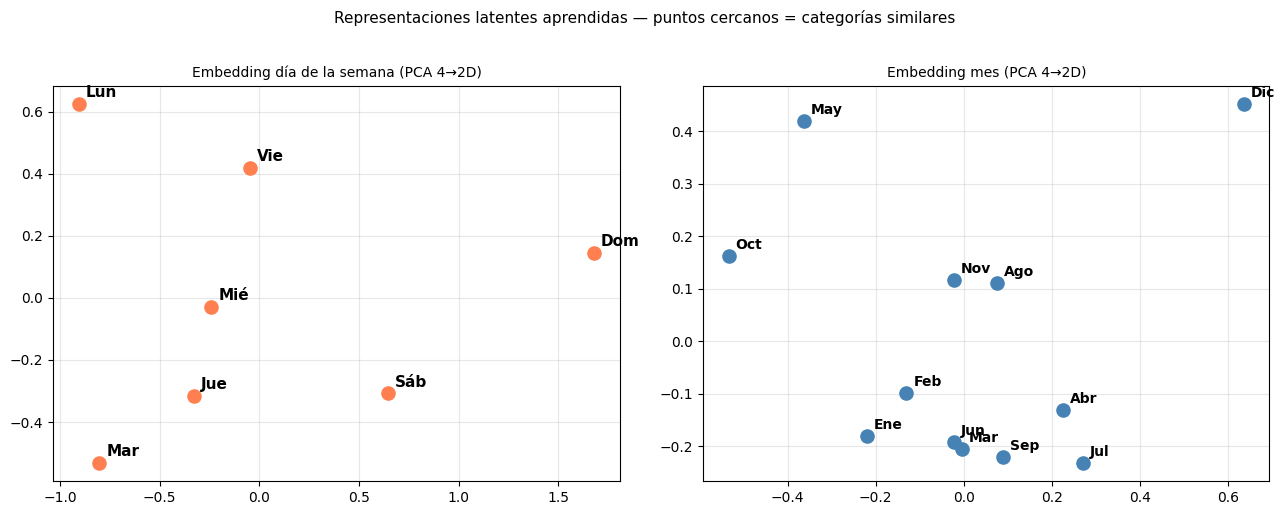

In [24]:
W_dow   = model.get_layer("emb_dow").get_weights()[0]    # (7, 4)
W_month = model.get_layer("emb_month").get_weights()[0]  # (12, 4)

pca_d   = PCA(n_components=2).fit(W_dow)
c_dow   = pca_d.transform(W_dow)
pca_m   = PCA(n_components=2).fit(W_month)
c_month = pca_m.transform(W_month)

dias  = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(c_dow[:, 0], c_dow[:, 1], s=90, color="coral", zorder=3)
for i, d in enumerate(dias):
    ax.annotate(d, c_dow[i], fontsize=11, fontweight="bold",
                xytext=(5, 5), textcoords="offset points")
ax.set_title("Embedding día de la semana (PCA 4→2D)", fontsize=10)
ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(c_month[:, 0], c_month[:, 1], s=90, color="steelblue", zorder=3)
for i, m in enumerate(meses):
    ax.annotate(m, c_month[i], fontsize=10, fontweight="bold",
                xytext=(5, 5), textcoords="offset points")
ax.set_title("Embedding mes (PCA 4→2D)", fontsize=10)
ax.grid(alpha=0.3)

plt.suptitle("Representaciones latentes aprendidas — puntos cercanos = categorías similares",
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

## 9 · Log de experimentos

| # | Fecha | Modelo | Épocas | LSTM | Emb temporales | Mejor val_loss | R² test global | R² (excl. 733/769) | Notas |
|---|-------|--------|--------|------|----------------|----------------|----------------|--------------------|-------|
| 1 | 2026-06-05 | v2 | 10/50 | 64 | dow(7→4) + month(12→4) | 0.8819 (ep.2) | 0.607 | 0.748 | Baseline — 10 épocas, checkpoint ep.2 |

---

### Experimento #1 — 2026-06-05
- **Modelo:** v2 (LSTM 64 + embeddings temporales dow/month)
- **Épocas ejecutadas:** 10 de 50 planificadas
- **Mejor checkpoint:** época 2 (val_loss = 0.8819)
- **LR schedule:** 0.001 → 0.0005 en época 8 (ReduceLROnPlateau patience=5)
- **R² test por tienda:**

| Tienda | R² | Tienda | R² |
|--------|-----|--------|-----|
| 5 | 0.927 | 1 | 0.669 |
| 3 | 0.837 | 4 | 0.668 |
| 2 | 0.799 | 733 | 0.438 |
| 562 | 0.689 | **769** | **−0.212** |
| 682 | 0.675 | | |

- **Observaciones:** Tienda 769 falla por tendencia alcista no capturada (subestimación ~9%). Tienda 733 sorprendentemente baja. El modelo necesita las 50 épocas completas con EarlyStopping para evaluarse justamente.

---

### Plantilla de nota de experimento

**Experimento #N**
- Fecha:
- Cambios respecto al anterior:
- Épocas / mejor epoch:
- R² val (mejor epoch):
- R² test por tienda: *(copiar tabla del report)*
- Observaciones: